<a href="https://colab.research.google.com/github/ruchira0011/Electricity-Demand-Forecasting-in-Great-Britain/blob/main/Uk_Energy_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Data

In [1]:
import pandas as pd

# List of NESO Historic Demand CSV URLs (you can extend this list)
urls = {
    2026: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/8a4a771c-3929-4e56-93ad-cdf13219dea5/download/demanddata_2026.csv",
    2025: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/b2bde559-3455-4021-b179-dfe60c0337b0/download/demanddata_2025.csv",
    2024: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/f6d02c0f-957b-48cb-82ee-09003f2ba759/download/demanddata_2024.csv",
    2023: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/bf5ab335-9b40-4ea4-b93a-ab4af7bce003/download/demanddata_2023.csv",
    2022: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/bb44a1b5-75b1-4db2-8491-257f23385006/download/demanddata_2022.csv",
    2021: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/18c69c42-f20d-46f0-84e9-e279045befc6/download/demanddata_2021.csv",
    2020: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/33ba6857-2a55-479f-9308-e5c4c53d4381/download/demanddata_2020.csv",
    2019: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/dd9de980-d724-415a-b344-d8ae11321432/download/demanddata_2019.csv",
    2018: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/fcb12133-0db0-4f27-a4a5-1669fd9f6d33/download/demanddata_2018.csv",
    2017: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/2f0f75b8-39c5-46ff-a914-ae38088ed022/download/demanddata_2017.csv",
    2016: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/3bb75a28-ab44-4a0b-9b1c-9be9715d3c44/download/demanddata_2016.csv",
    2015: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/cc505e45-65ae-4819-9b90-1fbb06880293/download/demanddata_2015.csv",
    2014: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/b9005225-49d3-40d1-921c-03ee2d83a2ff/download/demanddata_2014.csv",
    2013: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/2ff7aaff-8b42-4c1b-b234-9446573a1e27/download/demanddata_2013.csv",
    2012: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/4bf713a2-ea0c-44d3-a09a-63fc6a634b00/download/demanddata_2012.csv",
    2011: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/01522076-2691-4140-bfb8-c62284752efd/download/demanddata_2011.csv",
    2010: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/b3eae4a5-8c3c-4df1-b9de-7db243ac3a09/download/demanddata_2010.csv"
}

def load_neso_demand(urls: dict) -> pd.DataFrame:
    dfs = []
    for year, url in urls.items():
        print(f"Loading {year} data...")
        df_year = pd.read_csv(url)
        df_year["Year"] = year  # optional: keep track of source year
        dfs.append(df_year)
    return pd.concat(dfs, ignore_index=True)

df = load_neso_demand(urls)

print("Shape:", df.shape)
print(df.head())
print(df.columns)

Loading 2026 data...
Loading 2025 data...
Loading 2024 data...
Loading 2023 data...
Loading 2022 data...
Loading 2021 data...
Loading 2020 data...
Loading 2019 data...
Loading 2018 data...
Loading 2017 data...
Loading 2016 data...
Loading 2015 data...
Loading 2014 data...
Loading 2013 data...
Loading 2012 data...
Loading 2011 data...
Loading 2010 data...
Shape: (284592, 24)
  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND FORECAST_ACTUAL_INDICATOR    TSD  \
0      2026-01-01                  1  25107                         A  29668   
1      2026-01-01                  2  25881                         A  30361   
2      2026-01-01                  3  25355                         A  30681   
3      2026-01-01                  4  24762                         A  30225   
4      2026-01-01                  5  24111                         A  29092   

   ENGLAND_WALES_DEMAND  EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                 23625                      3978                

# Data Preprocessing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df.drop(columns=['SCOTTISH_TRANSFER','NSL_FLOW','ELECLINK_FLOW','VIKING_FLOW',
                 'GREENLINK_FLOW', 'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW',
                 'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW'], inplace=True)

# 1. Convert date column to datetime
df["SETTLEMENT_DATE"] = pd.to_datetime(df["SETTLEMENT_DATE"], format='mixed',
                                       dayfirst=True)

# 2. Ensure settlement period is numeric
df["SETTLEMENT_PERIOD"] = pd.to_numeric(df["SETTLEMENT_PERIOD"])

# 3. Create full timestamp (each period = 30 minutes)
df["timestamp"] = df["SETTLEMENT_DATE"] + pd.to_timedelta(
    (df["SETTLEMENT_PERIOD"] - 1) * 30, unit="min"
)

# 4. Set timestamp as index
df = df.set_index("timestamp")

# 5. Sort by time
df = df.sort_index()

# 6. Assign demand column
demand_col = "ND"
demand = df[demand_col]

# 7. Basic dataset info
print("Data shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())

# 8. Demand statistics
print(demand.describe())


# missing value handling
# Missingness
missing = df.isna().mean().sort_values(ascending=False) * 100
print("Top missing % columns:")
display(missing.head(10))

# Duplicates in time index
dup_count = df.index.duplicated().sum()
print("Duplicate timestamps:", dup_count)

# If duplicates exist, aggregate them
if dup_count > 0:
    df = df.groupby(df.index).mean(numeric_only=True)
    print("After aggregating duplicates -> shape:", df.shape)


Data shape: (284592, 13)
Date range: 2010-01-01 00:00:00 to 2026-03-31 23:30:00
count    284592.000000
mean      30569.458281
std        7698.419276
min       12803.000000
25%       24408.000000
50%       29769.000000
75%       36142.000000
max       59095.000000
Name: ND, dtype: float64
Top missing % columns:


,0
FORECAST_ACTUAL_INDICATOR,98.566369
SETTLEMENT_DATE,0.000000
SETTLEMENT_PERIOD,0.000000
ND,0.000000
TSD,0.000000
ENGLAND_WALES_DEMAND,0.000000
EMBEDDED_WIND_GENERATION,0.000000
EMBEDDED_WIND_CAPACITY,0.000000
EMBEDDED_SOLAR_GENERATION,0.000000
EMBEDDED_SOLAR_CAPACITY,0.000000


Duplicate timestamps: 32
After aggregating duplicates -> shape: (284560, 11)


In [3]:
# Select demand series
series = df["ND"]
series

,ND
timestamp,
2010-01-01 00:00:00,36453.0
2010-01-01 00:30:00,36680.0
2010-01-01 01:00:00,36343.0
2010-01-01 01:30:00,35362.0
2010-01-01 02:00:00,34366.0
...,...
2026-03-31 21:30:00,27169.0
2026-03-31 22:00:00,25638.0
2026-03-31 22:30:00,24861.0


# LSTM Model

In [4]:
# -------------------------------
# 0. REPRODUCIBILITY (SEED)
# -------------------------------
import numpy as np
import tensorflow as tf
import random
import os

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# -------------------------------
# 1. IMPORTS
# -------------------------------
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------------
# 2. DATA PREPARATION (3-hour)
# -------------------------------
series = df["ND"].resample("3h").mean().dropna()

# Train/Test split
train = series[:'2023']
test  = series['2024':]

# -------------------------------
# 3. SCALING
# -------------------------------
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
test_scaled  = scaler.transform(test.values.reshape(-1,1))

# -------------------------------
# 4. CREATE SEQUENCES
# -------------------------------
def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

SEQ_LEN = 48

X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_test, y_test   = create_sequences(test_scaled, SEQ_LEN)

# -------------------------------
# 5. BUILD MODEL
# -------------------------------
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(SEQ_LEN,1)))
model.add(Dropout(0.2))

model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

# -------------------------------
# 6. TRAIN MODEL
# -------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 48, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,369 (243.63 KB)

 Trainable params: 62,369 (243.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 63s 99ms/step - loss: 0.0214 - mae: 0.1198 - val_loss: 0.0105 - val_mae: 0.0844
Epoch 2/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 55s 96ms/step - loss: 0.0084 - mae: 0.0717 - val_loss: 0.0036 - val_mae: 0.0482
Epoch 3/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 56s 96ms/step - loss: 0.0049 - mae: 0.0549 - val_loss: 0.0030 - val_mae: 0.0437
Epoch 4/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 81s 94ms/step - loss: 0.0038 - mae: 0.0478 - val_loss: 0.0024 - val_mae: 0.0391
Epoch 5/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 57s 99ms/step - loss: 0.0030 - mae: 0.0421 - val_loss: 0.0021 - val_mae: 0.0359
Epoch 6/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 55s 96ms/step - loss: 0.0026 - mae: 0.0393 - val_loss: 0.0021 - val_mae: 0.0357
Epoch 7/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 56s 97ms/step - loss: 0.0023 - mae: 0.0374 - val_loss: 0.0016 - val_mae: 0.0314
Epoch 8/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 59s 102ms/step - loss: 0.0022 - mae: 0.0365 - val_loss: 0.0016 - val_mae: 0.0310
Epoch 9/15
575/575 ━━━━━━━━━━━━━━━━━━━━

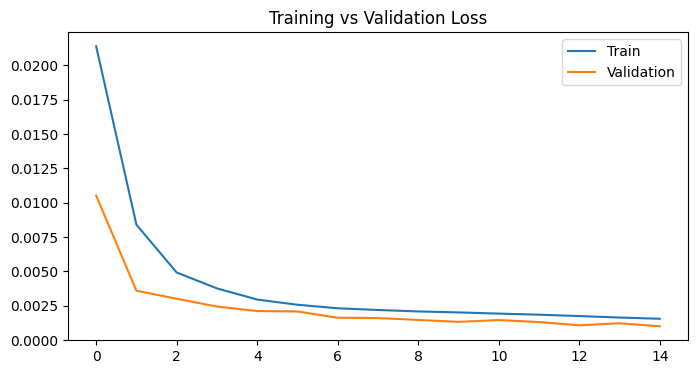

203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step
LSTM MAE: 1294.9319340256352
LSTM RMSE: 1718.1626868446854


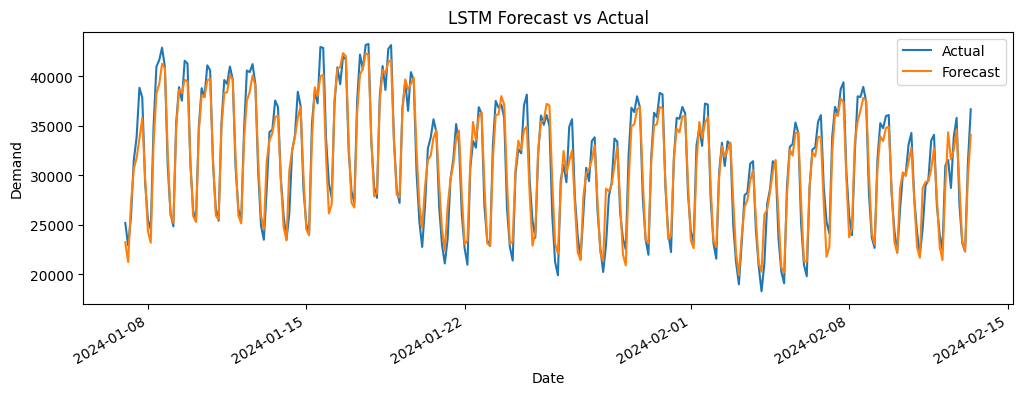

In [5]:
# 6. ploting training
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


# 7. PREDICTIONS
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)
y_test_real = scaler.inverse_transform(y_test)


# 8. EVALUATION
mae = mean_absolute_error(y_test_real, pred)
rmse = np.sqrt(mean_squared_error(y_test_real, pred))

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)


# 9. PLOT RESULTS
# Get correct time index for test set
test_index = test.index[SEQ_LEN:]  # skip first 48 due to sequence creation

plt.figure(figsize=(12,4))
plt.plot(test_index[:300], y_test_real[:300], label="Actual")
plt.plot(test_index[:300], pred[:300], label="Forecast")
plt.legend()
plt.title("LSTM Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.gcf().autofmt_xdate() # Add this line to automatically format x-axis dates
plt.show()

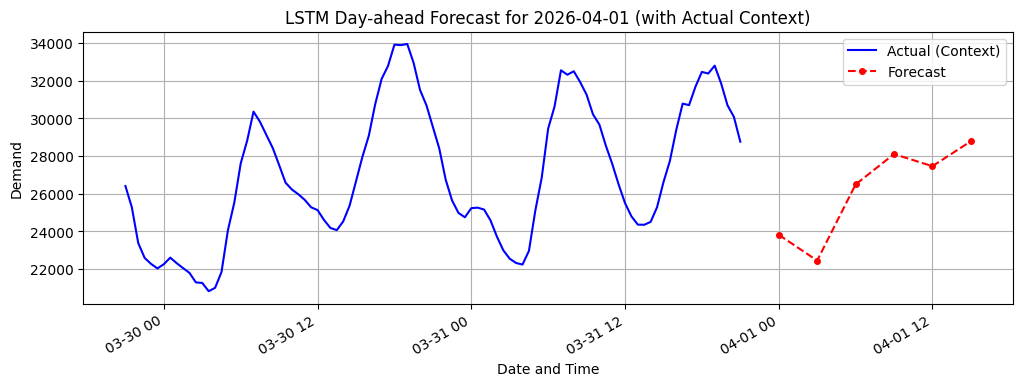

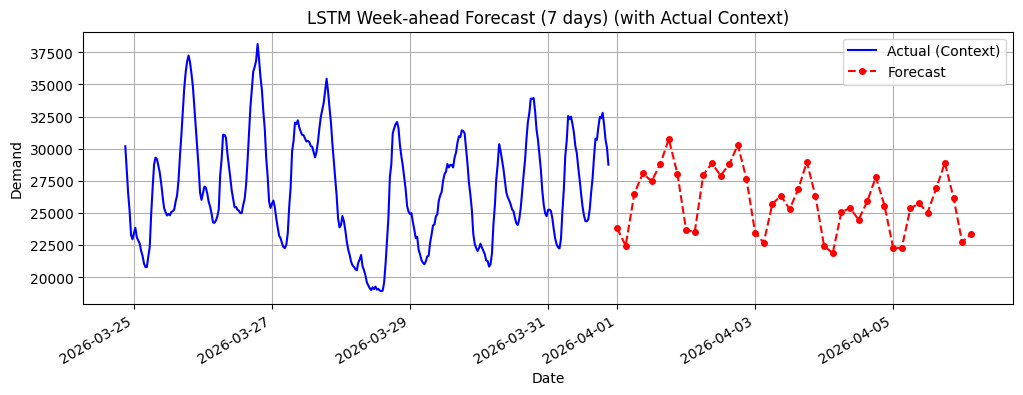

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
# STEP 1: Take last known sequence
# -------------------------------
last_seq = test_scaled[-SEQ_LEN:]

# Get the last timestamp from the 'test' series
last_timestamp = test.index[-1]

# -------------------------------
# STEP 2: DAY-AHEAD FORECAST (6 steps)
# -------------------------------
day_preds = []
seq_day_ahead = last_seq.copy() # Use a new sequence variable for clarity

for _ in range(6):  # 6 steps = 18 hours (3h data)
    x = seq_day_ahead.reshape(1, SEQ_LEN, 1)
    current_step_pred = model.predict(x, verbose=0)[0][0] # Renamed 'pred' to 'current_step_pred'

    day_preds.append(current_step_pred)

    # move window forward
    seq_day_ahead = np.append(seq_day_ahead[1:], current_step_pred)

# -------------------------------
# STEP 3: WEEK-AHEAD FORECAST (42 steps)
# -------------------------------
week_preds = []
seq_week_ahead = last_seq.copy() # Use a new sequence variable for clarity

for _ in range(42):  # 42 steps = 126 hours (3h data)
    x = seq_week_ahead.reshape(1, SEQ_LEN, 1)
    current_step_pred = model.predict(x, verbose=0)[0][0] # Renamed 'pred' to 'current_step_pred'

    week_preds.append(current_step_pred)

    # move window forward
    seq_week_ahead = np.append(seq_week_ahead[1:], current_step_pred)

# -------------------------------
# STEP 4: Convert back to real values
# -------------------------------
day_preds = scaler.inverse_transform(np.array(day_preds).reshape(-1,1))
week_preds = scaler.inverse_transform(np.array(week_preds).reshape(-1,1))

# -------------------------------
# STEP 5: Create time index for plotting
# -------------------------------
# Create forecast indices with correct 3h frequency
forecast_day_index = pd.date_range(start=last_timestamp + pd.Timedelta(hours=3), periods=len(day_preds), freq='3h')
week_index = pd.date_range(start=last_timestamp + pd.Timedelta(hours=3), periods=len(week_preds), freq='3h')

# -------------------------------
# STEP 6: Plot Day-ahead (Actuals + Forecast)
# -------------------------------
plt.figure(figsize=(12,4))

# Get actual context data from the original half-hourly df["ND"]
# This will make the 'Actual (Context)' line appear smooth.
original_half_hourly_series = df["ND"] # df is the half-hourly dataframe
context_start_day = last_timestamp - pd.Timedelta(days=2)
actual_context_day_data_smooth = original_half_hourly_series.loc[context_start_day : last_timestamp]


plt.plot(actual_context_day_data_smooth.index, actual_context_day_data_smooth.values, label="Actual (Context)", color='blue')
plt.plot(forecast_day_index, day_preds, label="Forecast", color='red', linestyle='--', marker='o', markersize=4) # Added markers for clarity on discrete predictions

forecast_start_time = last_timestamp + pd.Timedelta(hours=3)
forecast_start_date_str = forecast_start_time.strftime('%Y-%m-%d')
plt.title(f"LSTM Day-ahead Forecast for {forecast_start_date_str} (with Actual Context)")

plt.xlabel("Date and Time")
plt.ylabel("Demand")
plt.legend()
plt.gcf().autofmt_xdate() # Auto-format dates for better readability
plt.grid(True)
plt.show()

# -------------------------------
# STEP 7: Plot Week-ahead (Actuals + Forecast)
# -------------------------------
plt.figure(figsize=(12,4))

# Get actual context data from the original half-hourly df["ND"]
context_start_week = last_timestamp - pd.Timedelta(days=7)
actual_context_week_data_smooth = original_half_hourly_series.loc[context_start_week : last_timestamp]

plt.plot(actual_context_week_data_smooth.index, actual_context_week_data_smooth.values, label="Actual (Context)", color='blue')
plt.plot(week_index, week_preds, label="Forecast", color='red', linestyle='--', marker='o', markersize=4) # Added markers

plt.title("LSTM Week-ahead Forecast (7 days) (with Actual Context)")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.gcf().autofmt_xdate() # Auto-format dates for better readability
plt.grid(True)
plt.show()

In [7]:
from sklearn.metrics import r2_score

# Re-calculate predictions and inverse transform to ensure 'pred' and 'y_test_real' are correct
# This addresses potential overwriting issues from other cells.
pred = model.predict(X_test)
pred = scaler.inverse_transform(pred)
y_test_real = scaler.inverse_transform(y_test)

# Define actual and predicted values for the first day and week of the test set
# Assuming 3-hour intervals, a day has 8 points, a week has 56 points.
actual_day = y_test_real.flatten()[:8]
pred_day = pred.flatten()[:8]

actual_week = y_test_real.flatten()[:56]
pred_week = pred.flatten()[:56]

# Day-ahead R²
r2_day = r2_score(actual_day, pred_day)

# Week-ahead R²
r2_week = r2_score(actual_week, pred_week)

print("Day-ahead R²:", r2_day)
print("Week-ahead R²:", r2_week)


203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step
Day-ahead R²: 0.8192135668696929
Week-ahead R²: 0.9455943042137538


In [ ]:
# Get correct time index for test set
test_index = test.index[SEQ_LEN:]  # skip first 48 due to sequence creation

plt.figure(figsize=(12,4))
plt.plot(test_index[:500], y_test_real[:500], label='Actual')
plt.plot(test_index[:500], pred[:500], label='Forecast')
plt.legend()
plt.title("LSTM Demand Forecast (with correct time axis)")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_absolute_error

configs = [
    {"seq":48, "units":32, "dropout":0.1},
    {"seq":48, "units":64, "dropout":0.2},
    {"seq":96, "units":64, "dropout":0.2}
]

results = []

for config in configs:
    SEQ_LEN = config["seq"]

    X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
    X_test, y_test   = create_sequences(test_scaled, SEQ_LEN)

    model = Sequential()

    # Layer 1
    model.add(LSTM(config["units"], return_sequences=True, input_shape=(SEQ_LEN,1)))
    model.add(Dropout(config["dropout"]))

    # Layer 2
    model.add(LSTM(config["units"]))
    model.add(Dropout(config["dropout"]))

    # Output
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')

    model.fit(
        X_train, y_train,
        epochs=5,          # keep small for tuning
        batch_size=32,
        verbose=0
    )

    pred = model.predict(X_test, verbose=0)

    pred = scaler.inverse_transform(pred)
    y_test_real = scaler.inverse_transform(y_test)

    mae = mean_absolute_error(y_test_real, pred)

    results.append((config, mae))

# Print results
for r in results:
    print(r)

best = min(results, key=lambda x: x[1])
print("\nBest config:", best)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


({'seq': 48, 'units': 32, 'dropout': 0.1}, 1570.5240775135314)
({'seq': 48, 'units': 64, 'dropout': 0.2}, 1369.8870679943818)
({'seq': 96, 'units': 64, 'dropout': 0.2}, 1362.9242227772704)

Best config: ({'seq': 96, 'units': 64, 'dropout': 0.2}, 1362.9242227772704)


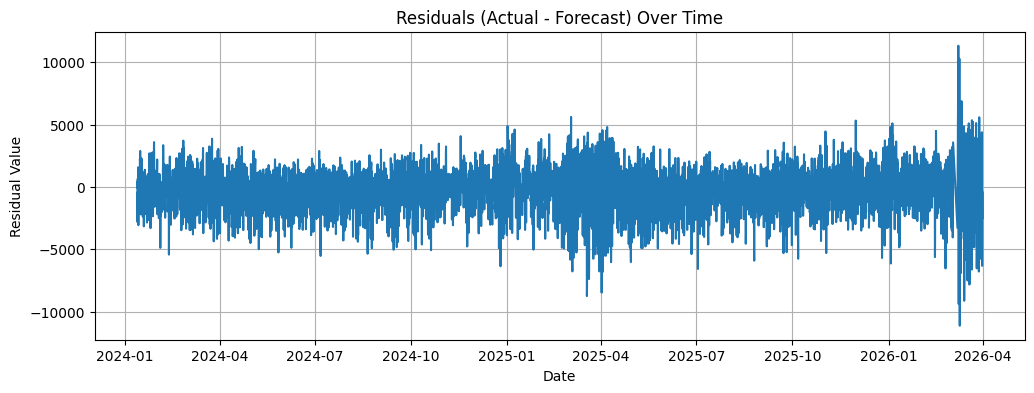

In [10]:
residuals = y_test_real.flatten() - pred.flatten()

# Get the corresponding time index for the residuals
# The test_index is already defined in previous cells and adjusted for SEQ_LEN
test_index_for_residuals = test.index[SEQ_LEN : SEQ_LEN + len(residuals)]

plt.figure(figsize=(12,4))
plt.plot(test_index_for_residuals, residuals)
plt.title("Residuals (Actual - Forecast) Over Time")
plt.xlabel("Date")
plt.ylabel("Residual Value")
plt.grid(True)
plt.show()